<a href="https://colab.research.google.com/github/smaldonado2004/labo_de_datos/blob/main/clase02_ldd_estadisticaDescriptiva_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

**Data Frames:**

Filas: observaciones

Columnas: variables

# Biblioteca Pandas, series y dataframes

Pandas es una biblioteca de Python muy usada para análisis y manipulación de datos. Provee principalmente dos tipos de clases para trabajar con datos:

- **Series:** un vector unidimensional indexado, que contiene datos de cualquier tipo
como números enteros, cadenas, objetos Python, etc.

- **DataFrame:** una estructura de datos bidimensional que contiene datos como una matriz bidimensional o una tabla con filas y columnas.

**Repaso Numpy**

In [ ]:
v = np.array([10,25.1])
v #devuelve mismo tipo de dato

array([10. , 25.1])

In [ ]:
v[1]

np.float64(25.1)

### Series

Las series de Pandas son vectores similares a los arrays de NumPy, que podemos indexar usando etiquetas.

**Ejercicio:** Crear la siguiente Series, observar qué devuelve `values` e `index` e interpretar.

In [ ]:
import pandas as pd
enteros = pd.Series([7,4,-5,3]) #pd.Series para def valores colum
enteros

,0
0,7
1,4
2,-5
3,3


In [ ]:
type(enteros.values) #son arrays de numpy

numpy.ndarray

In [ ]:
enteros.values #valores de la serie

array([ 7,  4, -5,  3])

In [ ]:
type(enteros) #serie

pandas.core.series.Series

In [ ]:
enteros.index # Por default, los índices van de 0 a N-1. STOP exclu

RangeIndex(start=0, stop=4, step=1)

Podemos asignar etiquetas (o índices) a cada valor de la serie.

In [ ]:
reales = pd.Series([np.pi,0,-2,1.41], index = ["a", "b", "c", "d"])
display(reales)
#a,b,c,d no es una columna +, es un indice

,0
a,3.141593
b,0.000000
c,-2.000000
d,1.410000


In [ ]:
print(reales) #se puede usar pero con display es mas organizado

a    3.141593
b    0.000000
c   -2.000000
d    1.410000
dtype: float64


In [ ]:
display(reales.values)
display(reales.index) #valores del indice

array([ 3.14159265,  0.        , -2.        ,  1.41      ])

Index(['a', 'b', 'c', 'd'], dtype='object')

Para acceder a los elementos podemos usar las etiquetas.

In [ ]:
print(reales["a"])

3.141592653589793


In [ ]:
# Para acceder por su posición usamos iloc
reales.iloc[1] #posicion contada desde cero

np.float64(0.0)

In [ ]:
# Podemos usar también rangos
reales.iloc[1:3]

,0
b,0.0
c,-2.0


In [ ]:
# Para acceder por etiquetas podemos usar también loc
# Observar que para rangos de etiquetas sí incluye la última etiqueta
reales.loc["a":"c"] #STOP no es exclu

,0
a,3.141593
b,0.000000
c,-2.000000


In [ ]:
reales.loc["a"]

np.float64(3.141592653589793)

In [ ]:
# Podemos definir indices como arrays
temperaturas = pd.Series([15, 17, 18.2, 25], index = np.array([5, 10, 15, 20]))
print(temperaturas)
#mido cada 5 dias las temp.

5     15.0
10    17.0
15    18.2
20    25.0
dtype: float64


In [ ]:
# Que esperamos de los siguientes comandos?
print("iloc", temperaturas.iloc[1:3]) #indice 1 y 2
print("loc", temperaturas.loc[10:20]) #10,15,20

iloc 10    17.0
15    18.2
dtype: float64
loc 10    17.0
15    18.2
20    25.0
dtype: float64


In [ ]:
# Funcionará?
temperaturas.iloc[10] #fuera de rango

IndexError: single positional indexer is out-of-bounds

In [ ]:
# Podemos seleccionar elementos mediante una lista de etiquetas
realesSub = reales[["a","b"]]
print(realesSub) #da las etiquetas a y b
print(realesSub.index)

a    3.141593
b    0.000000
dtype: float64
Index(['a', 'b'], dtype='object')


## Operaciones con series
Las operaciones que pueden **aplicarse a numpy arrays pueden aplicarse también a series de Pandas, conservando los índices.**

In [ ]:
reales

,0
a,3.141593
b,0.000000
c,-2.000000
d,1.410000


In [ ]:
np.exp(reales) #np.exp(5) es e elevado a la 5
#aplica a cda fila

,0
a,23.140693
b,1.000000
c,0.135335
d,4.095955


In [ ]:
reales * 3 #cda fila

,0
a,9.424778
b,0.000000
c,-6.000000
d,4.230000


In [ ]:
reales > 1 #bool de cda fila

,0
a,True
b,False
c,False
d,True


In [ ]:
reales[reales > 1] #solo devuelve las filas q lo cumplen

,0
a,3.141593
d,1.410000


¿Qué esperamos que dé este código?

In [ ]:
print(enteros)
print(reales)

0    7
1    4
2   -5
3    3
dtype: int64
a    3.141593
b    0.000000
c   -2.000000
d    1.410000
dtype: float64


In [ ]:
enteros + reales #no tienen las mismas etiquetas/indices (una es nros. y la otra es letras)

,0
0,NaN
1,NaN
2,NaN
3,NaN
a,NaN
b,NaN
c,NaN
d,NaN


**NaN** significa "not a number", se utiliza en series de Pandas para valores faltantes (missing values).

In [ ]:
# Y ahora?
enteros2 = pd.Series([1,2,3,4], index = ["d", "b", "y", "z"])
enteros2

,0
d,1
b,2
y,3
z,4


In [ ]:
suma = reales + enteros2 #solo suma los indi. similares
suma

,0
a,NaN
b,2.00
c,NaN
d,2.41
y,NaN
z,NaN


Vemos que solo se suman aparecen valores en las filas con índices que aparecen en las dos series.

In [ ]:
# Los floats de Numyp aceptan el valor np.nan.
print("tipo",type(np.nan))
# Qué resultados esperamos?
print(3 + np.nan) #es como hacer 3 + un dato faltante = dato faltante
print(0 * np.nan)
print(np.nan - np.nan)

tipo <class 'float'>
nan
nan
nan


Las series de Pandas tienen varias funciones útiles que iremos viendo más adelante. A modo de ejemplo, interpretar qué hacen las siguientes funciones.

In [ ]:
series1 = pd.Series(["a", "b", "c", "b", "a", "c", "x"])
series1

,0
0,a
1,b
2,c
3,b
4,a
5,c
6,x


In [ ]:
series1.isin(["b", "c"]) #bool si esta en la serie

,0
0,False
1,True
2,True
3,True
4,False
5,True
6,False


In [ ]:
# Qué hace este método?
series1.value_counts() #frecuencia de la serie

,count
a,2
b,2
c,2
x,1


In [ ]:
# Ejercicio: cómo me quedo solo con las filas con valores "b" o "c"?
series1[series1.isin(["b", "c"])]

,0
1,b
2,c
3,b
5,c


### DataFrames
Un data frame es una representación de los datos en formato de tabla en la que cada
columna son vectores del mismo tamaño. Como cada columna es un vector, **cada columna puede
contener datos de un único tipo**. Se pueden pensar como variables. Cada variable corresponde a una
serie de Pandas, y **todas las series de un dataframe están indexadas por los mismos índices**.

Una forma de crear un data frame es utilizando un "diccionario". **Todas las variables del
diccionario deben ser vectores o listas de la misma longitud.**

In [ ]:
data = {"nombres": ["Rodrigo", "Sergio", "Cristina", "Diana"], "altura": np.array([178, 172, 175, 168]), "peso": np.array
([81.2, 76.1, 68.5, 64.0])}
display(data)

{'nombres': ['Rodrigo', 'Sergio', 'Cristina', 'Diana'],
 'altura': array([178, 172, 175, 168]),
 'peso': array([81.2, 76.1, 68.5, 64. ])}

In [ ]:
type(data)

dict

In [ ]:
data["peso"]

array([81.2, 76.1, 68.5, 64. ])

In [ ]:
# Creamos un data frame con esos datos. Cuáles son los índices? Por defoult desde el cero
pacientes = pd.DataFrame(data)
pacientes

,nombres,altura,peso
0,Rodrigo,178,81.2
1,Sergio,172,76.1
2,Cristina,175,68.5
3,Diana,168,64.0


In [ ]:
# En este ejemplo podemos usar los nombres como índices
pacientes = pd.DataFrame(data).set_index("nombres") #pero tmb podria ser set_index("altura")
display(pacientes)

,altura,peso
nombres,,
Rodrigo,178,81.2
Sergio,172,76.1
Cristina,175,68.5
Diana,168,64.0


In [ ]:
# Podemos acceder a las columnas de dos formas distintas
alturas = pacientes["altura"]
alturas

,altura
nombres,
Rodrigo,178
Sergio,172
Cristina,175
Diana,168


In [ ]:
pes = pacientes["peso"]
pes

,peso
nombres,
Rodrigo,81.2
Sergio,76.1
Cristina,68.5
Diana,64.0


In [ ]:
# Esto a veces es más práctico, pero hay que tener cuidado que el nombre usado no tenga otro significado o símbolos o espacios
pacientes.altura

,altura
nombres,
Rodrigo,178
Sergio,172
Cristina,175
Diana,168


In [ ]:
type(alturas)

pandas.core.series.Series

In [ ]:
alturas.dtype #tipo del contenido

dtype('int64')

A diferencia de las matrices en Numpy, un DataFrame de Pandas es un conjunto de columnas, no de filas.
Si queremos saber la altura de Rodrigo, pensar cuál de los dos comandos será correcto antes de ejecutarlos.

In [ ]:
pacientes

,altura,peso
nombres,,
Rodrigo,178,81.2
Sergio,172,76.1
Cristina,175,68.5
Diana,168,64.0


In [ ]:
pacientes["Rodrigo"].altura

KeyError: 'Rodrigo'

In [ ]:
pacientes["altura"].Rodrigo #accedo x la colum. y luego busco la fila

np.int64(178)

Para acceder a una fila de un dataframe, podemos usar los métodos `loc[]` y `iloc[]`.

¿Cómo se usan? ¿Cuál es la diferencia entre los dos comandos? ¿Que tipo de dato nos devuelve?

In [ ]:
#Para los de Rodrigo:
pacientes.loc["Rodrigo"] #convierte todo al mismo tipo de dato

#si tenia otro dato con str, el dtype me da un object (pyhton no reconoce el tipo)

,Rodrigo
altura,178.0
peso,81.2


In [ ]:
#ahora puedo hacer con lo anterior:
pacientes.loc["Rodrigo"].altura

np.float64(178.0)

In [ ]:
pacientes.iloc[0] #como en series

,Rodrigo
altura,178.0
peso,81.2


## Archivos de datos

La biblioteca Pandas nos permite trabajar fácilmente con archivos de datos.
1. Leer el archivo casos_coronavirus.csv . (csv: datos separados por comas) En colab lo subo manualmente a archivos cada que trabaje con el mismo".
2. Graficar la curva de casos por día.
3. Graficar la curva de casos acumulados.
4. Definir log_cum_casos como el logaritmo de la cantidad de casos acumulados y graficar en función de la cantidad de días transcurridos.
5. Estimar, tomando dos valores, la pendiente de la recta para los datos a partir del dia 30.
6. Graficar la recta estimada junto con los datos. ¿Consideran que es una buena estimación?


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("casos_coronavirus.csv") # Para cargar el DataFrame
df.head()  # Da las primeras filas del DataFrame
#los indices estan por default

,fecha,confirmados_Nuevos
0,3-3-2020,1
1,4-3-2020,0
2,5-3-2020,1
3,6-3-2020,6
4,7-3-2020,0


In [ ]:
# Información básica del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   fecha               96 non-null     object
 1   confirmados_Nuevos  96 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.6+ KB


In [ ]:
# ¿Cómo usamos la fecha como índice?
df = pd.read_csv("casos_coronavirus.csv").set_index("fecha")
df

,confirmados_Nuevos
fecha,
3-3-2020,1
4-3-2020,0
5-3-2020,1
6-3-2020,6
7-3-2020,0
...,...
2-6-2020,904
3-6-2020,949
4-6-2020,929


<Axes: xlabel='fecha'>

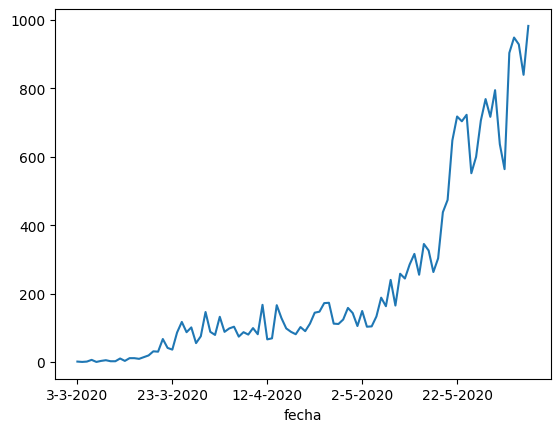

In [ ]:
# Graficamos utilizando el método plot de series de Pandas (llama matplotlip)
df["confirmados_Nuevos"].plot()
#el indice es el eje x

<Axes: xlabel='fecha'>

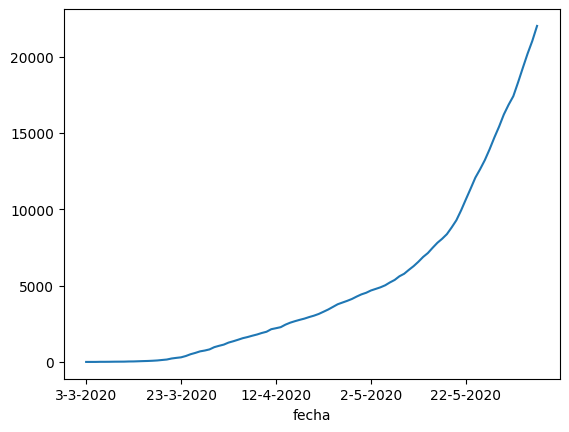

In [ ]:
# Queremos graficar los casos acumulados, podemos usar el método cumsum() de series Pandas
df.confirmados_Nuevos.cumsum().plot()
#Casos acumulados refiere a juntar/sumar los casos en intervalos de fecha, mostrando una tendencia + general

**Ejercicio**
Esta serie presenta un crecimiento exponencial.
Queremos tomar logaritmos para linealizar, ¿como podemos hacerlo?


Graficar los valores obtenidos.

<Axes: xlabel='fecha'>

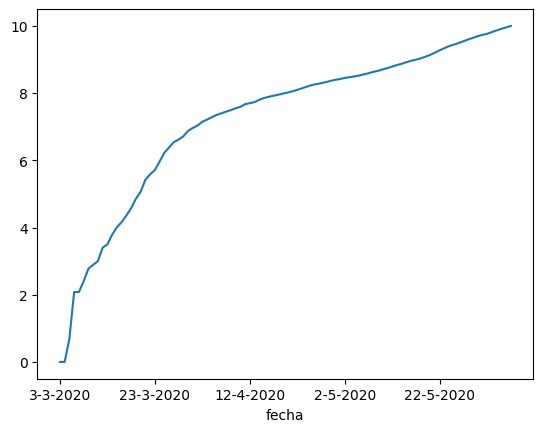

In [ ]:
casos = np.log(df.confirmados_Nuevos.cumsum())
casos.plot()

**Ejercicio.** Estimar la pendiente de la recta antes del confinamiento (dias 5 al 25) y la pendiente de la recta después del confinamiento. Graficas las rectas para verificar la estimación.

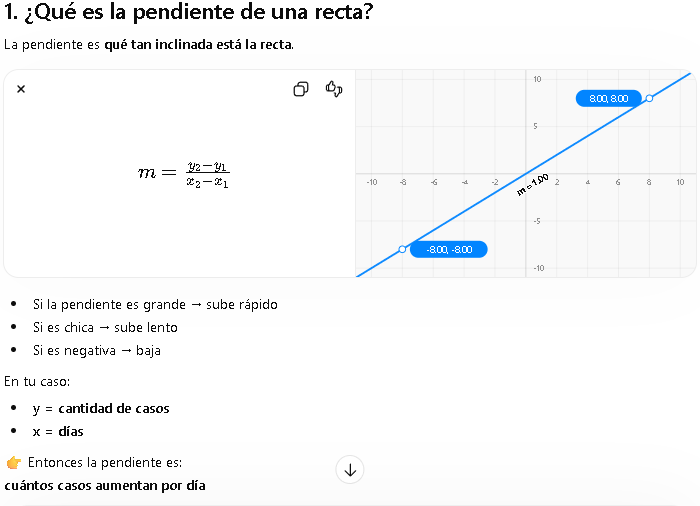

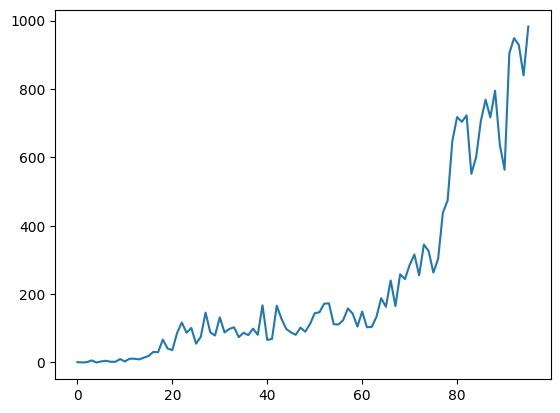

In [ ]:
casos = df.confirmados_Nuevos.reset_index(drop = True)  # Reseteamos índices para ver mejor el gráfico y estimar mejor la pendiente.
plt.plot(casos)

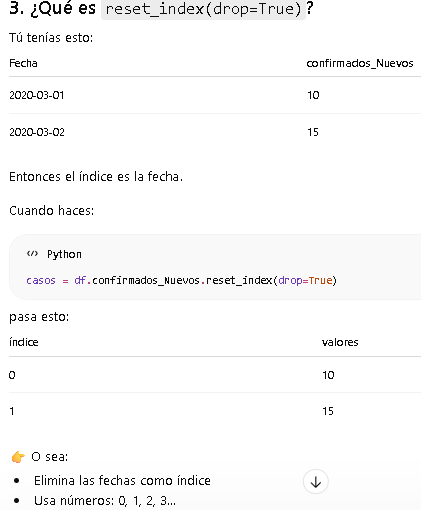

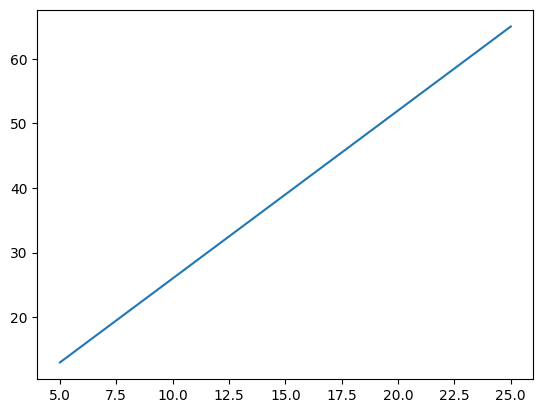

In [ ]:
casos_antes = casos[5:26] #como empieza desde el dia 0 entonces, mi rango va del dia 5 hasta el dia 25

y1 = casos_antes.iloc[0] #valor casos dia 5
y2 = casos_antes.iloc[-1] #valor casos dia 25

x1 = 0
#empleo x1= 0 pq al generar casos[5:26] mi indice comienza en 0 q corresponde al dia 5
x2 = len(casos_antes) - 1 #menos uno pq empiezo desde x1 = 0

pendiente = (y2 - y1) / (x2 - x1)
# Graficamos la recta
x_recta = casos_antes.index

#en y debe ir la misma cantidad de valores que en x. Es decir, para un valor de x le corresponde uno en y
y_recta = pendiente * x_recta #por eso multiplico por cada valor x
plt.plot(x_recta, y_recta)

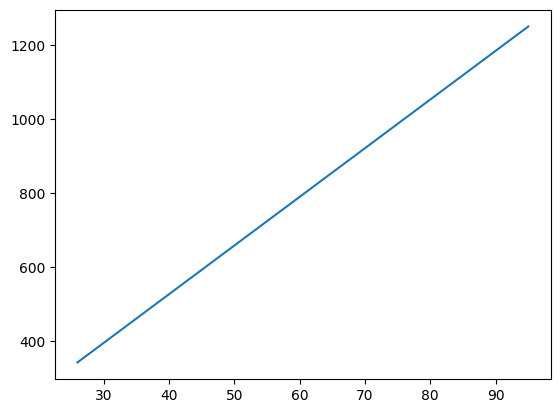

In [ ]:
#Despues del confinamiento:
casos_despues = casos[26:len(casos) +1]
y1 = casos_despues.iloc[0] #valor casos dia 26
y2 = casos_despues.iloc[-1] #valor casos ultimo dia

x1 = 0
x2 = len(casos_despues) - 1

pendiente = (y2 - y1) / (x2 - x1)

#Para graficar:
x_plano = casos_despues.index
y_plano = pendiente * x_plano

plt.plot(x_plano, y_plano)

## Gapminder

A modo de ejemplo, vamos a explorar el dataset Gapminder que contiene datos poblacionales y de desarrollo humano de distintos países a lo largo del tiempo.

Si gapminder no está instalado, ejecutar el siguiente comando para instalarlo (o sea es lo mismo que cuando subimos el archivo, pero aqui lo instalamos).

In [3]:
%pip install gapminder

In [4]:
from gapminder import gapminder

In [ ]:
# Verificamos si se cargo correctamente
display(gapminder)

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


**Pregunta:** Podemos usar alguna columna como índice? No pq existen datos repetidos, pero podemos indexar por pais y año (multiindices) no dado en la materia.

In [ ]:
# Para ver las primeras cinco filas
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


Podemos ver información básica del DataFrame con la función info

In [ ]:
gapminder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


In [ ]:
# Vemos todos los países en la base
gapminder["country"].unique() #unique sin repetidos

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Australia', 'Austria', 'Bahrain', 'Bangladesh', 'Belgium',
       'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Czech Republic',
       'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia',
       'Finland', 'France', 'Gabon', 'Gambia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Haiti',
       'Honduras', 'Hong Kong, China', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Korea, Dem. Rep.',
       'Korea, Rep.', 'Kuwait', 'Leba

In [ ]:
# Cuántos países son?
gapminder["country"].nunique()

142

O podemos usar el atributo `size` de series de Pandas.

In [ ]:
gapminder["country"].unique().size

142

### Entrada en calor

1. Cuál era la población de Argentina en 1967?
2. En qué países la expectativa de vida era mayor que 80 años en 2002? (filtrar la tabla para dejar solo las filas correspondientes)
   

UNO

In [ ]:
argentina = gapminder[(gapminder["country"] == "Argentina") & (gapminder["year"] == 1967)]
argentina["pop"]

,pop
51,22934225


DOS

In [ ]:
expe_vida = gapminder[(gapminder["lifeExp"] > 80) & (gapminder["year"] ==2002)]
expe_vida["country"]

,country
70,Australia
670,"Hong Kong, China"
694,Iceland
778,Italy
802,Japan
1474,Sweden
1486,Switzerland


### groupby

In [ ]:
# Si queremos ver cuántos países hay en cada continente...
# podemos agregupar por continente y ver el tamaño de cada grupo
gapminder.groupby("continent").size()    # Para un dataframe agrupado, size es un método x eso lleva ()!

,0
continent,
Africa,624
Americas,300
Asia,396
Europe,360
Oceania,24


In [ ]:
# Pero cada país aparece varias veces, con datos de distintos años.
# Para contar sin repeticion usamos nuevamente nunique
cantidades = gapminder.groupby("continent")["country"].nunique()
cantidades

,country
continent,
Africa,52
Americas,25
Asia,33
Europe,30
Oceania,2


In [ ]:
#Los indices pasan a ser lo que tiene adentro groupby
cantidades.index

Index(['Africa', 'Americas', 'Asia', 'Europe', 'Oceania'], dtype='object', name='continent')

In [ ]:
#Yo lo pongo asi pq es una fila pero tmb se puede acceder con []
cantidades.Africa

np.int64(52)

In [ ]:
# Que tipo de dato nos devolvió?
cantidades["Africa"]

np.int64(52)

In [ ]:
# Si queremos calcular porcentajes, dividimos por la cantidad total de paises
#Es decir, queremos ver “¿Qué porcentaje de los países del mundo están en cada continente?”
totalPaises = gapminder["country"].nunique()

# (cant. paises que tiene cada continente / total del paises del mundo) * 100 para %
res = (gapminder.groupby("continent")["country"].nunique() / totalPaises) * 100
res

,country
continent,
Africa,36.619718
Americas,17.605634
Asia,23.239437
Europe,21.126761
Oceania,1.408451


### value_counts

In [ ]:
gapminder[["continent", "country"]] #mostrar dos column. separando x coma

,continent,country
0,Asia,Afghanistan
1,Asia,Afghanistan
2,Asia,Afghanistan
3,Asia,Afghanistan
4,Asia,Afghanistan
...,...,...
1699,Africa,Zimbabwe
1700,Africa,Zimbabwe
1701,Africa,Zimbabwe
1702,Africa,Zimbabwe


In [ ]:
gapminder[["continent", "country"]].drop_duplicates() #elimino las filas repetidas

,continent,country
0,Asia,Afghanistan
12,Europe,Albania
24,Africa,Algeria
36,Africa,Angola
48,Americas,Argentina
...,...,...
1644,Asia,Vietnam
1656,Asia,West Bank and Gaza
1668,Asia,"Yemen, Rep."
1680,Africa,Zambia


In [ ]:
# O podemos usar el comando value_counts y pasarle un parámetro para que nos de los valores normalizados.
# (la normalización lleva la suma total a 1)
gapminder[["continent", "country"]].drop_duplicates().continent.value_counts(normalize=True)

,proportion
continent,
Africa,0.366197
Asia,0.232394
Europe,0.211268
Americas,0.176056
Oceania,0.014085


**Que hace normalize = True (la suma de la normalizacion da uno**
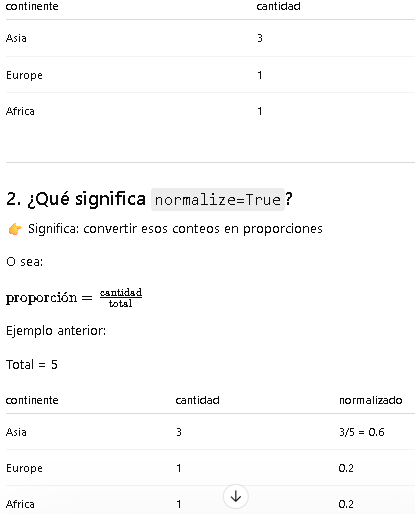

In [ ]:
# Vemos todos los años disponibles
gapminder["year"].unique()

array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

In [ ]:
# Tenemos datos de todos los países todos los años? Si pq el nro de vaces que aparece cada anio es constante
# Agrupamos los datos por año y calculamos el tamaño de cada bloque
gapminder.groupby("year").size()

,0
year,
1952,142
1957,142
1962,142
1967,142
1972,142
1977,142
1982,142
1987,142
1992,142


In [ ]:
# Ejercicio: cómo podemos hacerlo utilizando value_counts?
  #Cuántos paises hay para cada año:
gapminder["year"].value_counts()

,count
year,
1952,142
1957,142
1962,142
1967,142
1972,142
1977,142
1982,142
1987,142
1992,142


In [ ]:
# Ejercicio: cómo podemos calcular la poblacion total por año
#primero agrupo los anios y luego suma la pop de cada anio
gapminder.groupby(["year"])["pop"].sum()

,pop
year,
1952,2406957150
1957,2664404580
1962,2899782974
1967,3217478384
1972,3576977158
1977,3930045807
1982,4289436840
1987,4691477418
1992,5110710260


### Gráficos simples de funciones o puntos en el plano XY.
Vamos a graficar la población total mundial en función del año.

In [ ]:
pobAnual = gapminder.groupby("year")["pop"].sum() #como antes suma la pop para cada anio agrupado
type(pobAnual) #es una serie pq esta agrupada x anios

pandas.core.series.Series

In [ ]:
pobAnual

,pop
year,
1952,2406957150
1957,2664404580
1962,2899782974
1967,3217478384
1972,3576977158
1977,3930045807
1982,4289436840
1987,4691477418
1992,5110710260


In [ ]:
pobAnual.index #da los anios

Index([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002, 2007], dtype='int64', name='year')

<Axes: xlabel='year'>

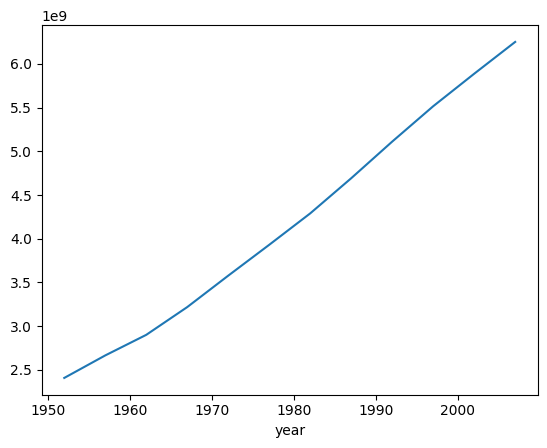

In [ ]:
# Opción 1
# Usamos la función plot de series de pandas
pobAnual.plot() #asume x como indice la la colum como y

<Axes: xlabel='year'>

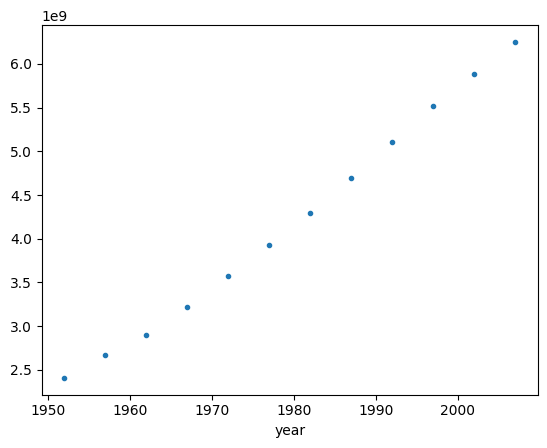

In [ ]:
# O podemos graficar solo puntos
pobAnual.plot(style = ".")

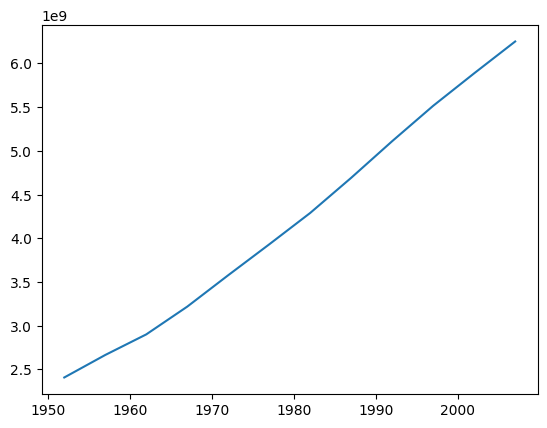

In [ ]:
# Opcion 3
# Asignamos los valores a variables (arrays de numpy) y graficamos las variables
x = pobAnual.index
y = pobAnual.values
plt.plot(x,y)

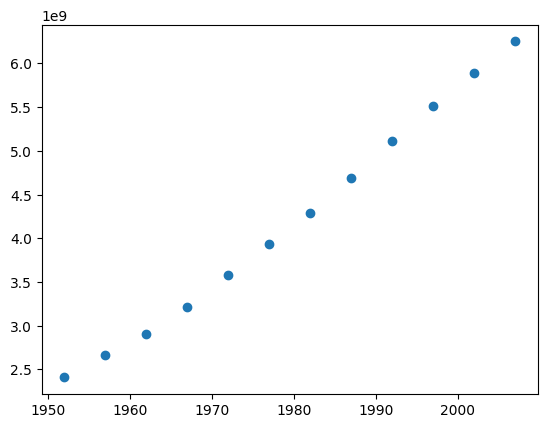

In [ ]:
# Opcion 4
# Matplotlib tiene una función scatter para graficar puntos
plt.scatter(x,y)

## Estadística descriptiva

In [5]:
# Vamos a analizar los datos de 2007
datos2007 = gapminder[gapminder["year"]==2007]
datos2007

,country,continent,year,lifeExp,pop,gdpPercap
11,Afghanistan,Asia,2007,43.828,31889923,974.580338
23,Albania,Europe,2007,76.423,3600523,5937.029526
35,Algeria,Africa,2007,72.301,33333216,6223.367465
47,Angola,Africa,2007,42.731,12420476,4797.231267
59,Argentina,Americas,2007,75.320,40301927,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906
1691,Zambia,Africa,2007,42.384,11746035,1271.211593


In [6]:
# Queremos usar los países como índices
datos2007.set_index("country")

,continent,year,lifeExp,pop,gdpPercap
country,,,,,
Afghanistan,Asia,2007,43.828,31889923,974.580338
Albania,Europe,2007,76.423,3600523,5937.029526
Algeria,Africa,2007,72.301,33333216,6223.367465
Angola,Africa,2007,42.731,12420476,4797.231267
Argentina,Americas,2007,75.320,40301927,12779.379640
...,...,...,...,...,...
Vietnam,Asia,2007,74.249,85262356,2441.576404
West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798
"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906


In [7]:
# Funcionó? No pq no estoy asignando a la variable datos2007
datos2007

,country,continent,year,lifeExp,pop,gdpPercap
11,Afghanistan,Asia,2007,43.828,31889923,974.580338
23,Albania,Europe,2007,76.423,3600523,5937.029526
35,Algeria,Africa,2007,72.301,33333216,6223.367465
47,Angola,Africa,2007,42.731,12420476,4797.231267
59,Argentina,Americas,2007,75.320,40301927,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906
1691,Zambia,Africa,2007,42.384,11746035,1271.211593


In [8]:
# Para guardar los cambios, lo asignamos a la misma variable
datos2007 = datos2007.set_index("country")
datos2007

,continent,year,lifeExp,pop,gdpPercap
country,,,,,
Afghanistan,Asia,2007,43.828,31889923,974.580338
Albania,Europe,2007,76.423,3600523,5937.029526
Algeria,Africa,2007,72.301,33333216,6223.367465
Angola,Africa,2007,42.731,12420476,4797.231267
Argentina,Americas,2007,75.320,40301927,12779.379640
...,...,...,...,...,...
Vietnam,Asia,2007,74.249,85262356,2441.576404
West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798
"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906


In [9]:
#Compruebo
datos2007

,continent,year,lifeExp,pop,gdpPercap
country,,,,,
Afghanistan,Asia,2007,43.828,31889923,974.580338
Albania,Europe,2007,76.423,3600523,5937.029526
Algeria,Africa,2007,72.301,33333216,6223.367465
Angola,Africa,2007,42.731,12420476,4797.231267
Argentina,Americas,2007,75.320,40301927,12779.379640
...,...,...,...,...,...
Vietnam,Asia,2007,74.249,85262356,2441.576404
West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798
"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906


In [ ]:
# O usamos la opcion inplace = True
datos2007 = gapminder[gapminder["year"]==2007]
datos2007.set_index("country", inplace = True) #obligamos a pandas a reemplazar el df(no lo usamos en la materia)
datos2007

,continent,year,lifeExp,pop,gdpPercap
country,,,,,
Afghanistan,Asia,2007,43.828,31889923,974.580338
Albania,Europe,2007,76.423,3600523,5937.029526
Algeria,Africa,2007,72.301,33333216,6223.367465
Angola,Africa,2007,42.731,12420476,4797.231267
Argentina,Americas,2007,75.320,40301927,12779.379640
...,...,...,...,...,...
Vietnam,Asia,2007,74.249,85262356,2441.576404
West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798
"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906


Mirando los datos de 2007, ¿cuál es el país con mayor expectativa de vida? ¿Cuál es el país con menor expectativa de vida?

In [ ]:
#empleo los comandos max y min
minimo = datos2007["lifeExp"].min() #la colum. con corchete
minimo

39.613

In [ ]:
max = datos2007["lifeExp"].max()
max

82.603

En matemática, cuando queremos saber para qué valor se alcanza el máximo, decimos que queremos saber el "argumento" del máximo. Esta funcion suele llamarse `argmax`. Utilizar la función de numpy np.argmax para responder las preguntas. Quiero saber cual es el pais q me da ese min:

In [ ]:
datos2007["lifeExp"].argmax() #nos da la fila

np.int64(66)

In [ ]:
#buscamos por fila
datos2007.iloc[66]

,Japan
continent,Asia
year,2007
lifeExp,82.603
pop,127467972
gdpPercap,31656.06806


La función de numpy devuelve la posición. Si queremos saber el índice, podemos usar el método de series de Panda idxmax().

In [10]:
datos2007["lifeExp"].idxmax()

'Japan'

### Medidas de tendencia central

Para el año 2007, calcular el valor medio y la mediana de las variables gdpPercap y lifeExp entre todos los países.
Son similares o distintas? A qué lo atribuyen? Consideran que alguna resume mejor la realidad que la otra?


In [ ]:
datos2007["lifeExp"].median()

71.93549999999999

In [ ]:
datos2007["lifeExp"].mean() #media

np.float64(67.00742253521126)

In [ ]:
datos2007["gdpPercap"].median()

6124.3711084999995

In [ ]:
datos2007["gdpPercap"].mean()

np.float64(11680.071819878167)

¿Es lo mismo el promedio de la expectativa de vida entre todos los países y el promedio de la expectativa de vida entre todas las personas?

No es lo mismo, ya que lo que hicimos fue `datos2007["lifeExp"].mean()` que es el **promedio entre paises** (todos valen igual).
Por ejemplo tengo:
 | país | vida | población |
| ---- | ---- | --------- |
| A    | 80   | 1         |
| B    | 60   | 100       |

El promedio normal:
(80 + 60) / 2 = 70

En cambio el **promedio entre personas es**:

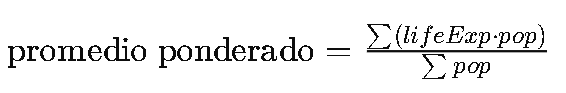

Por lo que el promedio entre personas toma en cuenta pop y es:

(80*  1 + 60* 100) / (1 + 100)

= (80 + 6000) / 101

≈ 60.2

¿Cuál calculamos arriba? Entre todos los paises

¿Cómo podemos calcular el otro?


In [11]:
#Creo una nueva colum. producto q tenga lifeExp*pop
datos2007["producto"] = datos2007["lifeExp"] * datos2007["pop"]
#sumo cada producto y div x el total de la pop
datos2007["producto"].sum() / datos2007["pop"].sum()
#Da un res + alto

np.float64(68.91909251904043)

In [12]:
datos2007 #se puede ver la nueva columna:

,continent,year,lifeExp,pop,gdpPercap,producto
country,,,,,,
Afghanistan,Asia,2007,43.828,31889923,974.580338,1.397672e+09
Albania,Europe,2007,76.423,3600523,5937.029526,2.751628e+08
Algeria,Africa,2007,72.301,33333216,6223.367465,2.410025e+09
Angola,Africa,2007,42.731,12420476,4797.231267,5.307394e+08
Argentina,Americas,2007,75.320,40301927,12779.379640,3.035541e+09
...,...,...,...,...,...,...
Vietnam,Asia,2007,74.249,85262356,2441.576404,6.330645e+09
West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798,2.950340e+08
"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906,1.392632e+09


### Medidas de dispersión

Para el año 2007, calcular la varianza y el desvío estándar de las variables gdpPercap y lifeExp entre todos los países. ¿Cuál es más fácil de interpretar? desvio estandar

In [ ]:
datos2007["lifeExp"].var() #varianza

145.75782404714806

In [ ]:
datos2007["lifeExp"].std() #desvio estandar

12.07302050222512